# Lab 2:   ATLAS Data Analysis



Reminder:  **Lab 2** needs to be submitted in the `Lab2` folder of your personal `PHYS265-spring26` github repo, with the two `lab2.ipynb` and `lab2.html` files.

Lab days: April 6 and 8, during normal class hours.  Report is due on Sunday April 12, at 11.59pm on github, not ELMS.

Avoiding confusion, enter your name here:    Krithik Mohan


## Introduction
------

Imagine you are a physicist working on the ATLAS (**A** **T**oroidal **L**hc **A**pparatu**S**) experiment at CERN in Geneva. At ATLAS, high energy protons are smashed together, and the byproducts are studied. One of the most important measurements to be made is the mass of the $Z^0$ boson.

After you have done your investigations — which you are guided through below — you will
prepare a short report on your findings for grad students in your research group in the form of this notebook. 

A table of relevant physical constants, from the 2024 edition of the Particle Data Group, is
below. Good luck!



| Quantity | Value |
|----------|-------|
|    Mass of Z Boson ($m_{Z^0}$) | $91.1880 \pm 0.0020$ GeV/$c^2$ |
|    Mass of W Boson ($m_W$) | $80.3692 \pm 0.0133$ GeV/$c^2$ |
|    Mass of Higgs Boson ($m_H$)   | $125.20 \pm 0.11$ GeV/$c^2$ |
|    Mass of Electron ($m_e$)   | $0.51099895000 \pm 0.00000000015$ MeV/$c^2$ |
|    Mass of Muon ($m_\mu$)   | $105.6583755 \pm 0.0000023$ MeV/$c^2$ |
|    Mass of Tau ($m_\tau$)   | $1776.93 \pm 0.09$ MeV/$c^2$ |


At the Large Hadron Collider, at CERN, in Geneva, Switzerland, particle physicists collide beams of protons.
This process breaks the protons open, and more fundamental particles are formed, interact, and decay.
One of the most interesting fundamental particles to come out of proton-proton ($pp$) interactions is the $Z^0$-boson, which is the neutral carrier of the *weak* force, and is therefore responsible, along with the $W^{\pm}$-boson, for facilitating many nuclear interactions in the Universe. The photon, which you are more familiar with, is the carrier of the *electromagnetic force*.

The $Z^0$ is unstable and decays. About 10\% of the time, it decays into a pair of charged leptons. 
This can be an electron ($e$) and and anti-electron (or positron, $e^+$).
It can also be a muon/anti-muon pair, or a tau/anti-tau pair.
Because it can do any of these, we substitute the generic letter $\ell$ for lepton, 
and this interaction is known as $Z^0 \rightarrow \ell \bar{\ell}$, 
where the ``bar" over the $\ell$ indicates an anti-particle.
Because charge cannot be created or destroyed, they must have opposite 
(or no\footnote{It is also possible for the $Z^0$ to decay into two photons, or $Z^0 \rightarrow \gamma \gamma$}) 
charge. And, because matter and energy cannot be created or destroyed, 
if $Z^0$ particles are decaying to produce the leptons, 
then the total energy stored in the two leptons must sum to (at least) the mass of the $Z^0$.
This means that if we can measure the energy of all double-lepton events in the detector, 
we should see an *excess* or a *peak* at the mass of the $Z_0$.





In [1]:
from ftplib import parse227

#show  start with your imports
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from scipy import stats
import scipy.stats as st

In [2]:
m_z = 91.1880
m_z_unc = 0.0020

import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from scipy import stats
import scipy.stats as st### Part 1: Invariant Mass Distribution
------

In the ATLAS detector (which is one of four main experiments at the LHC), 
it is reasonably straightforward to measure four properties of particles 
that come out of the proton-proton interactions. The first is the total energy $E$. 
The second is the transverse-momentum $p_T$, which describes the momentum 
the particle has in the transverse direction. The third is the pseudorapidity $\eta$, 
which describes the angle the particle makes with respect to the beamline. 
If the particle continues straight along the beamline, then $\eta \rightarrow \infty$, 
while if the particle is deflected out at $90^o$, it has $\eta =0$. 
The fourth is the azimuthal angle $\phi$ about the beam. 
That is, if you are staring down the barrel of the collider, a particle with $\eta, \phi = 0, 0$ 
emerges from the interaction point flying directly to the right. 
Where a particle with $\eta, \phi = 0, \pi/2$ emerges from the top flying straight up.

Together, these values fully define the *four momentum* of the particle: 
$p = (E, p_x, p_y, p_z)$ through the following mathematical relationships, 
where $c$ (the speed of light) is treated in a strange fashion and set equal to 1 
(which you will learn more about when you take a course that covers relativity and discuss "natural units"):

$$
p_x = p_T \cos(\phi), \,\,\,\,\, p_y = p_T \sin(\phi), \,\,\,\, p_z = p_T \sinh(\eta)    \tag{1}
$$


The difference between the three-momentum and the energy is the particle's invariant mass:

$$
M = \sqrt{E^2 - (p_x^2 + p_y^2 + p_z^2)}     \tag{2}
$$

If you have *two* particles, and you would like to know the total momentum of the system, 
you have to sum the four momenta: $p_{tot} = p_1 + p_2$.

In the file `atlas_z_to_ll.csv`, you will find five-thousand real ATLAS data events.
These have been pre-selected from the 
[2020 ATLAS open dataset](https://atlas.cern/Resources/Opendata)
so that the ``final states" only contain the two leptons we are interested in.
The first two columns are the $p_T$ (in GeV) for the two leptons; 
the next two columns are the $\eta$, the next two are $\phi$ (radians), 
and the last two are the energy $E$ (in GeV) 
**Note**: One nifty utility of natural units is that momentum and energy have the same units, which makes doing math with them much easier.


1. Load the data into python.
2. For each lepton pair, using the formulas in eq. (1) and eq. (2), calculate the mass of a hypothetical particle which decayed to produce that pair.
   * Hint: first, calculate the vector components, then calculate the summed four-momenta, then calculate the mass.
4. Make a histogram, with error bars, of your calculated invariant mass. You should approximate this as a Poisson counting experiment, so that the error on the number of events in the bin is equal to the square-root of the number of events in the bin. That is: $\sigma = \sqrt{N}$. Label the axes nicely, with units, etc. To make uniform grading possible, please do the histogram from 80 to 100 GeV with 41 bins. That is: `bins = np.linspace(80,100,41)`.


In [3]:
data = np.loadtxt("atlas_z_to_ll.csv", delimiter = ",", skiprows = 1)
p1 = data[:, 0]
p2 = data[:, 1]
eta1 = data[:, 2]
eta2 = data[:, 3]
phi1 = data[:, 4]
phi2 = data[:, 5]
E1 = data[:, 6]
E2 = data[:, 7]

p_x1 = p1* np.cos(phi1)
p_x2 = p2* np.cos(phi2)
p_y1 = p1* np.sin(phi1)
p_y2 = p2* np.sin(phi2)
p_z1 = p1*np.sinh(eta1)
p_z2 = p2*np.sinh(eta2)
p_x = p_x1 + p_x2
p_y = p_y1 + p_y2
p_z = p_z1 + p_z2
E = E1 + E2


m = np.sqrt(E**2- (p_x**2 + p_y**2 + p_z**2))

print(m)



[92.1500371  89.28245012 88.2747245  ... 89.49674175 67.40937294
 90.84796693]


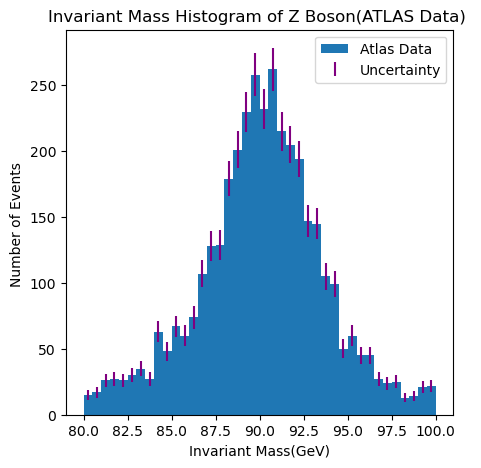

In [4]:
fig, ax = plt.subplots(figsize=(5,5))
bins = np.linspace(80, 100,41)

counts, bin_edges = np.histogram(m, bins=bins)
n = len(m)

error = np.sqrt(counts)

ax.hist(m, bins=bins, label = 'Atlas Data')
ax.set_xlabel("Invariant Mass(GeV)")
ax.set_ylabel("Number of Events ")
ax.set_title("Invariant Mass Histogram of Z Boson(ATLAS Data) ")
bin_center = (bin_edges[1:] + bin_edges[:-1])/2
ax.errorbar(bin_center, counts, yerr = error, fmt='none', ecolor='purple', label = "Uncertainty")
ax.legend()


### Part 2: Breit-Wigner Fit
------

You can show, using scattering theory, that the distribution of decays $\mathcal{D}$ at a reconstructed mass $m$ follows what is known as a Breit-Wigner (to a mathematician, Cauchy-Lorentz) peak. The distribution depends on true rest-mass of the $Z^0$, $m_0$, and on a "width" parameter $\Gamma$:

$$
\mathcal{D}(m; m_0, \Gamma) = \frac{1}{\pi} \frac{\Gamma/2}{(m-m_0)^2 + (\Gamma/2)^2}    \tag{3}
$$

In nature, the true width parameter $\Gamma_0$, is related to the lifetime of the particle by the Heisenberg uncertainty principle.
In a real detector, we can only measure the width subject to experimental uncertainties, and $\Gamma_{exp} > \Gamma_0$.


1. Code up a function that returns the decay distribution as a function of $m$, $m_0$, and $\Gamma$.
2.  Fit your mass-distribution with the Breit-Wigner function. Fix the overall normalization to half the number of data points in the set. That is, you should fit $\frac{5000}{2} \times \mathcal{D}$. To make
 uniform grading possible, please do the fitting where the bin centers are $>87$ to $<93$ GeV *only*. But keep the same 41 bins from 80 to 100. If you were to make a numpy mask, it would be: `mask = (bin_centers > 87) & (bin_centers < 93)`.
3. In a second, new plot, plot the data (with error bars), and overlay your fit. Label the axes well, add a nice legend, etc. In a sub-panel, plot the residuals between the data and the fit, and draw a hori
zontal line at zero to indicate perfect agreement (like we did in Lecture 13). Draw two vertical dotted lines to denote the fitting range.
4. Calculate the chi-square, reduced-chi-square, and p-value of your fit *in the fitting range*. 
5. Using the covariance matrix, calculate the best fit mass $m_0$, and its uncertainty. 
6. Annotate your plot with your best fit for the mass, its uncertainty, the chi-square/NDOF, and the p-value. Use only one decimal place for all numbers. 
7. Label this plot clearly as **Figure 1**.




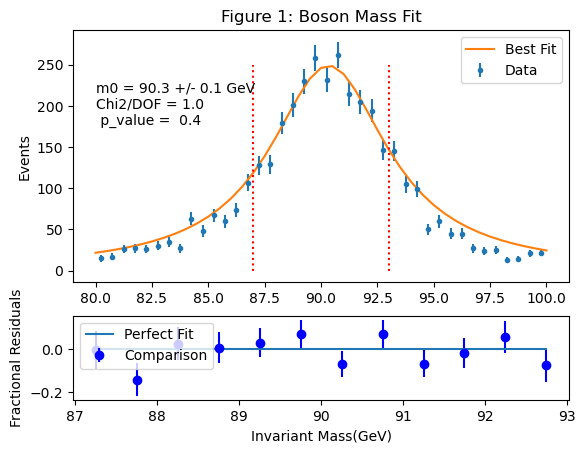

In [5]:
def D (m, m_0, T) :
    part1 = T/2
    part2 = (m-m_0)**2 +(T/2)**2
    return 2500* (part1/(np.pi*part2))


x = np.linspace(80, 100,41)
counts_forfit, edges_forfit = np.histogram(m, bins=x)
centers_forfit = (edges_forfit[:-1] + edges_forfit[1:])/2
error_forfit = np.sqrt(counts_forfit)

mask = (centers_forfit > 87) & (centers_forfit < 93)



x_fit = centers_forfit[mask]
y_fit = counts_forfit[mask]
y_err = error_forfit[mask]

guess = [90, 4]
params, pcov = curve_fit(D, x_fit, y_fit, p0 = guess, sigma = y_err, absolute_sigma= True)



mbest = params[0]
bbest = params[1]
best_fit = D(x_fit, mbest, bbest)

m0_unc = np.sqrt(pcov[0,0])
chi2 = np.sum(((y_fit- best_fit)/ y_err)**2)
d_of_f = len(x_fit)-2
red_chi2 = chi2/d_of_f
p_val = stats.chi2.sf(chi2, d_of_f)


fig, ax = plt.subplots(2, 1, gridspec_kw = {"height_ratios":[3, 1]})
ax[0].errorbar(centers_forfit, counts_forfit, yerr=error_forfit, fmt='.', label='Data')

ax[0].plot(x,D(x, *params), label='Best Fit')

# draw in the errors on x
ax[0].vlines(87, 0, 250,color = 'red', ls = ':')
ax[0].vlines(93, 0, 250,color = 'red', ls=':')


comp = (y_fit - best_fit)/best_fit
comp_error = y_err /best_fit

zeros= np.zeros(len(x_fit))
ax[1].errorbar(x_fit,comp,yerr = comp_error, fmt = "o", color="blue", label="Comparison")
ax[1].plot(x_fit,zeros,label="Perfect Fit")

annotation = f"m0 = {mbest:.1f} +/- {m0_unc:.1f} GeV\nChi2/DOF = {red_chi2:.1f}  \n p_value = {p_val : .1f}"

ax[0].text(80, 230, annotation, fontsize = 10, verticalalignment='top', horizontalalignment='left')
ax[0].set_title("Figure 1: Boson Mass Fit")
ax[0].set_ylabel("Events")
ax[1].set_ylabel("Fractional Residuals")
ax[1].set_xlabel("Invariant Mass(GeV)")
ax[1].legend()


ax[0].legend()

## Part 3: 2D Parameter Scan
----

As emphasized in class, this is a 2D fit, and you cannot determine $Z^0$ and $\Gamma_{exp}$ independently. In this part, you visualize the joint probability space.


1. Perform a 2D chi-square scan of the mass-width parameter space. To make grading easier, please scan in  mass from 89 to 91 GeV, and the width from 5 to 8, with 300 bins along each dimension. 
2. Make a filled contour plot of the $\Delta \chi^2 = \chi^2 - \chi^2_{min}$. Clip the $\Delta \chi^2$ at 35 units to make the plot easier to see. Add a colorbar. Make the plot look nice, with appropriate labels. Note that this is a $\Delta \chi^2$ map. This means the minimum value on the z-axis should be zero.
3. Draw the $1\sigma$ and $3\sigma$ confidence levels onto the plot using a solid and dashed line, respectively.  Use the matplotlib `clabel` capability to label the levels appropriately.
   * Hint 1: If you need a refresher on how to do this, please check [this matplotlib page](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_label_demo.html)
   * Hint 2: You can look up the $\Delta \chi^2$ corresponding to the $1\sigma$ and $3\sigma$ levels online, or they can be seen in Lecture **11**. Pay close attention to how many degrees of freedom you have.
5. Draw a dot/cross at the best fit location from Part 2.
6. Label this plot clearly as **Figure 2**.




Text(0.5, 0, ' Mass $M_0$ (GeV)')

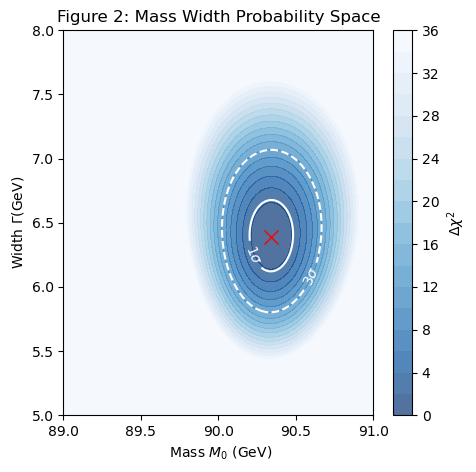

In [6]:
m_val = np.linspace(89,91,300)
width =np.linspace (5,8,300)

chi2_grid = np.zeros((len(width), len(m_val)))

x, y = np.meshgrid(m_val, width)

fig, ax = plt.subplots(figsize = (5,5))


for i in range(len(width)):
    for j in range(len(m_val)):
        val = D(x_fit, m_val[j], width[i])
        chi23 = np.sum(((y_fit-val)/y_err)**2)
        chi2_grid[i, j] = chi23

chimin = np.min(chi2_grid)

deltachi = chi2_grid-chimin

deltaclip = np.clip(deltachi, 0, 35)

c = ax.contourf(x,y,deltaclip, levels = 20, cmap ="Blues_r", alpha = 0.7)

cbar = fig.colorbar(c, ax = ax)
cbar.set_label(rf"$\Delta \chi^2$")

levels = [2.3, 11.83]
cs = ax.contour (x, y, deltachi, levels = levels, colors =['white', 'white'], linestyles = ['solid', 'dashed'])


ax.clabel(cs,inline=True, fmt={levels[0]:r"$1 \sigma$", levels[1]:r"$3\sigma$"})

ax.plot(mbest, bbest, 'rx', markersize = 10, label = "Best Fit")
ax.set_title("Figure 2: Mass Width Probability Space")


ax.set_ylabel(rf"Width $\Gamma$(GeV)" )
ax.set_xlabel(rf" Mass $M_0$ (GeV)")


Boson Mass Distribution## Part 4: Discussion and Future Work
----

Add a brief comparison of your measured $Z^0$ relative to
the latest accepted values from the PDG. It should also include a summary of the approximations
you have made in doing your calculations, and future work necessary to make the calculations
more realistic. For example, your fit does not include any systematic uncertainties, or the energy
resolution of the ATLAS detector.


**Your Answer Goes in the markdown cell below:**


In [7]:
total_unc = np.sqrt( m_z_unc**2 + m0_unc**2)
difference = np.abs(m_z-mbest)
comparison = difference/total_unc
print(comparison)

9.057397726000755


A quantitative comparison between the accepted mass of Z bosons (91.188 $\pm$ 0.002 GeV) and the calculated value of Z bosons ($90.3 \pm 0.1$ GeV) revealed a difference of around 9.06 $\sigma$. In experiments, two measurements being within 2 $\sigma$ indicates a good fit. My value of 9.06 $\sigma$ means that the values are inconsistent with each other, indicating statistical inconsistency between the calculated value and the accepted value above. This is due to not taking multiple other factors into account, as well as making assumptions. Our fit does not include systematic uncertainties. The systematic uncertainties are not taken into account, leading to consistent differences in answers from the actual answer, which need to be accounted for to get the most accurate answer. In addition, the fit used was a Breit-Wigner distribution. However, the ATLAS detector has a limited energy resolution that leads to values being wider than their expected values. When looking for more accurate theoretical models, I found the Voigt Profile, which was a Breit-Wigner combined with a Gaussian for better modeling. In addition, there is an assumption of no background made. The theoretical model assumes that all the data received represents the Z decay. However, in real life, with current instruments, other processes create background signals that introduce noise and errors into the data, leading to overestimation, which leads to a less accurate answer. In addition, there is another assumption made that the detector detects all processes in its area. In reality, there are blind spots where the number of events found by the detector is not fully caught due to blind spots in the detector, leading to an underestimation in the total event count.

In [8]:
!jupyter nbconvert --to html lab2.ipynb


[NbConvertApp] Converting notebook lab2.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][8]['outputs'][1]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAAAeEAAAHUCAYAAAAN/ZAQAAAAOXRFWHRTb2Z0d2Fy...',
          'text/plain': '<Figure size 500x500 with 1 Axes>'},
 'jetTransient': {'display_id': None},
 'metadata': {},
 'output_type': 'display_data'}
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 477239 bytes to lab2.html
